# Statistical Analysis of Radioastron OJ287 Observations

## Imports

**Comment**: Below are provided imports.

In [222]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

## Methods

**Comment**: Below are provided additional global methods to use in the Notebook.

In [180]:
def jd_from_datetime(dt):
    if pd.isna(dt):
        return np.nan
    year = dt.year
    month = dt.month
    day = dt.day
    hour = dt.hour + dt.minute/60.0 + dt.second/3600.0
    
    if month <= 2:
        year -= 1
        month += 12
    A = year // 100
    B = 2 - A + (A // 4)
    jd = int(365.25 * (year + 4716)) + int(30.6001 * (month + 1)) + day + B - 1524.5
    jd += hour / 24.0
    return jd

In [223]:
def average_flux_near_epoch(lightcurve,
                            jd,
                            flux_col,
                            window=10):

    mask = np.abs(lightcurve["JD"] - jd) <= window

    if mask.sum() == 0:
        return np.nan

    return lightcurve.loc[mask, flux_col].mean()

In [225]:
def correlation_plot(ax,
                     df,
                     xcol,
                     xlabel):

    tmp = df[[xcol, "Tb"]].dropna()

    ax.scatter(
        tmp[xcol],
        tmp["Tb"],
        s=50,
        alpha=0.7
    )

    ax.set_yscale("log")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$T_b$ (K)")

    if len(tmp) >= 3:

        p = pearsonr(tmp[xcol], tmp["Tb"])

        s = spearmanr(tmp[xcol], tmp["Tb"])

        ax.set_title(
            f"Pearson={p.statistic:.2f} (p={p.pvalue:.3f})\n"
            f"Spearman={s.statistic:.2f} (p={s.pvalue:.3f})",
            fontsize=10
        )

    ax.grid(alpha=0.3)

In [229]:
def scatter_corr(ax, x, y, xlabel, ylabel, logx=False, logy=False):

    mask = (
        np.isfinite(x) &
        np.isfinite(y)
    )

    x = np.asarray(x)[mask]
    y = np.asarray(y)[mask]

    ax.scatter(
        x,
        y,
        s=60,
        alpha=0.75,
        edgecolor="k",
        linewidth=0.4
    )

    if logx:
        ax.set_xscale("log")

    if logy:
        ax.set_yscale("log")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.grid(alpha=0.3)

    if len(x) > 2:

        r, p = pearsonr(x, y)
        rs, ps = spearmanr(x, y)

        ax.set_title(
            f"Pearson = {r:.3f} (p={p:.3f})\n"
            f"Spearman = {rs:.3f} (p={ps:.3f})",
            fontsize=10
        )

        print("-------------------------------------")
        print(xlabel, "vs", ylabel)
        print(f"Pearson : {r:.3f}   p={p:.4f}")
        print(f"Spearman: {rs:.3f}   p={ps:.4f}")

## Globals

**Comment**: Below are provided global variables.

In [181]:
# description of observational frequency bands
# P -- 316 MHz
# L -- 1668 MHz
# C -- 4828 MHz
# K -- 22236 MHz

bands = ['P', 'L', 'C', 'K']
bands_without_p = ['L', 'C', 'K']

# designation of colors for corresponding frequency bands
band_colors = {
    'L': "#c3ff74",
    'C': "#a6f7e3",
    'K': "#86b9c9"
}

## Data Loading & Preparation

### Data Loading

**Comment**: Load datasets.

In [182]:
df = pd.read_csv('Observations_Table.txt', sep='\t')
ang = pd.read_csv('Data_Table.txt', sep='\t')
flux = pd.read_csv('AAVSO_Light_Curve.txt', sep='\t')
ratan = pd.read_csv('RATAN_Light_Curves.txt', sep='\t')
fermit = pd.read_csv('FermiLAT_Light_Curve.txt', sep='\t')
swift = pd.read_csv('Swift_Light_Curve.txt', sep='\t')

**Comment**: Get basic information about datasets.

#### Observations Table

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Obs. Code         92 non-null     object 
 1   Start date/time   92 non-null     object 
 2   Stop date/time    92 non-null     object 
 3   Telescopes        92 non-null     object 
 4   BL, (ED)          88 non-null     float64
 5   Bands             92 non-null     object 
 6   Tracking station  54 non-null     object 
 7   P                 92 non-null     object 
 8   L                 92 non-null     object 
 9   C                 92 non-null     object 
 10  K                 92 non-null     object 
dtypes: float64(1), object(10)
memory usage: 8.0+ KB


In [184]:
df.head()

,Obs. Code,Start date/time,Stop date/time,Telescopes,"BL, (ED)",Bands,Tracking station,P,L,C,K
0,raes03f,21.02.2012 1:30,21.02.2012 2:30,"GRT:Eb (C),Ys (C),Mc (L),Ev (L)",12.0,CL,NaN,x,0,1,x
1,raes03i,17.03.2012 15:00,17.03.2012 16:00,"GRT:Nt,Ev,Mc,Us",10.0,LC,NaN,x,2,0,x
2,raes03p,04.04.2012 18:30,04.04.2012 19:30,"GRT:Ef (C),Ys(C),Nt (C),Ev (L)",5.0,CL,NaN,x,1,1,x
3,raes03q,05.04.2012 17:00,05.04.2012 18:00,"GRT:Ef (C),Ys (C),Nt (C),Ev (L)",5.0,CL,NaN,x,1,1,x
4,raes03aa,27.04.2012 21:30,27.04.2012 23:30,GRT:Ar (C: 21:30-22:00; L: 22:05-22:30; P: 22:...,12.0,CLP,NaN,0,1,1,x


#### Angular Size Table

In [185]:
ang.head()

,Obs,Band,Date,Frequency,Theta_rad,Theta_rad_err,Theta_mas,Theta_mas_err,Y0,Y0_err,A0,A0_err
0,RAES03AA,C,2012-04-27,4828,5.623820e-10,6.043870e-12,0.116,0.001,0.00000,0.00000,1.82470,0.01301
1,RAES03AB,C,2012-04-28,4828,8.223090e-10,3.783600e-11,0.170,0.008,0.00000,0.00000,1.41168,0.01634
2,RAES03FW,C,2012-11-19,4828,3.105990e-09,9.651350e-10,0.641,0.199,0.04239,0.00535,2.34019,0.29095
3,RAES03FW,L,2012-11-19,1668,2.360400e-09,3.565680e-11,0.487,0.007,0.00000,0.00000,1.65010,0.00562
4,RAES03P,C,2012-04-04,4828,1.197850e-09,8.629210e-11,0.247,0.018,0.00000,0.00000,3.60793,0.05398


In [186]:
ang.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Obs            72 non-null     object 
 1   Band           72 non-null     object 
 2   Date           72 non-null     object 
 3   Frequency      72 non-null     int64  
 4   Theta_rad      72 non-null     float64
 5   Theta_rad_err  72 non-null     float64
 6   Theta_mas      72 non-null     float64
 7   Theta_mas_err  72 non-null     float64
 8   Y0             72 non-null     float64
 9   Y0_err         72 non-null     float64
 10  A0             72 non-null     float64
 11  A0_err         72 non-null     float64
dtypes: float64(8), int64(1), object(3)
memory usage: 6.9+ KB


#### Optical Light Curve Table

In [187]:
flux.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7523 entries, 0 to 7522
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   JD                    7523 non-null   float64
 1   Magnitude             7523 non-null   object 
 2   Uncertainty           6339 non-null   float64
 3   HQuncertainty         0 non-null      float64
 4   Band                  7521 non-null   object 
 5   Observer Code         7523 non-null   object 
 6   Comment Code(s)       160 non-null    object 
 7   Comp Star 1           4951 non-null   object 
 8   Comp Star 2           4163 non-null   object 
 9   Charts                7409 non-null   object 
 10  Comments              1667 non-null   object 
 11  Transfomed            6691 non-null   float64
 12  Airmass               5285 non-null   float64
 13  Validation Flag       7523 non-null   object 
 14  Cmag                  3859 non-null   float64
 15  Kmag                 

In [188]:
flux.head()

,JD,Magnitude,Uncertainty,HQuncertainty,Band,Observer Code,Comment Code(s),Comp Star 1,Comp Star 2,Charts,...,Cmag,Kmag,HJD,Star Name,Observer Affiliation,Measurement Method,Grouping Method,ADS Reference,Digitizer,Credit
0,2.455980e+06,15.406,0.02,NaN,V,GCO,NaN,ENSEMBLE,000-BBQ-007,1502KG,...,NaN,13.941,NaN,OJ 287,AAVSO,STD,NaN,NaN,NaN,NaN
1,2.455985e+06,15.1,0.20,NaN,V,HUR,NaN,150,NaN,JT060319,...,15.0,NaN,NaN,OJ 287,BAA-VSS,STD,NaN,NaN,NaN,NaN
2,2.455985e+06,15.08,NaN,NaN,V,PYG,NaN,S,NaN,251.02,...,14.6,NaN,NaN,OJ 287,NaN,STD,NaN,NaN,NaN,NaN
3,2.455985e+06,15.0,NaN,NaN,Vis.,STI,NaN,146,153,"6025en,ee",...,NaN,NaN,NaN,OJ 287,AAVSO,STD,NaN,NaN,NaN,NaN
4,2.455987e+06,15.0,NaN,NaN,Vis.,PYG,B,S-4,NaN,251.02,...,NaN,NaN,NaN,OJ 287,NaN,STD,NaN,NaN,NaN,NaN


#### RATAN Radio Light Curve Table

In [189]:
ratan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           77 non-null     object
 1   21.7/22.3 GHz  77 non-null     object
 2   Unnamed: 2     77 non-null     object
 3   14.4 GHz       77 non-null     object
 4   Unnamed: 4     77 non-null     object
 5   11.2 GHz       77 non-null     object
 6   Unnamed: 6     77 non-null     object
 7   7.7/8.2 GHz    77 non-null     object
 8   Unnamed: 8     77 non-null     object
 9   4.8 GHz        77 non-null     object
 10  Unnamed: 10    77 non-null     object
 11  2.3 GHz        77 non-null     object
 12  Unnamed: 12    77 non-null     object
 13  1.1 GHz        77 non-null     object
 14  Unnamed: 14    77 non-null     object
dtypes: object(15)
memory usage: 9.2+ KB


In [190]:
ratan.head()

,Date,21.7/22.3 GHz,Unnamed: 2,14.4 GHz,Unnamed: 4,11.2 GHz,Unnamed: 6,7.7/8.2 GHz,Unnamed: 8,4.8 GHz,Unnamed: 10,2.3 GHz,Unnamed: 12,1.1 GHz,Unnamed: 14
0,15.04.2009,4.08,0.47,-,-,3.44,0.11,2.66,0.11,1.95,0.07,1.24,0.09,-,-
1,15.04.2011,7.82,0.87,-,-,6.85,0.24,5.64,0.11,4.5,0.09,-,-,-,-
2,15.07.2011,6.76,0.9,-,-,6.19,0.18,5.93,0.18,4.96,0.17,-,-,-,-
3,15.08.2011,4.38,0.44,-,-,5.21,0.16,5.44,0.22,4.85,0.15,-,-,-,-
4,15.09.2011,4.01,0.49,-,-,5.08,0.24,5.3,0.28,4.66,0.19,-,-,-,-


#### Fermi Light Curve Table

In [191]:
fermit.head()

,MJD,FLUX_100_300000,ERROR_100_300000
0,54688.500743,9.577098e-08,2.965300e-09
1,54689.500743,1.209674e-07,1.607956e-09
2,54690.500743,1.684671e-07,1.643102e-09
3,54691.500743,3.231207e-07,7.945157e-08
4,54692.500743,2.073799e-07,1.584371e-07


In [192]:
fermit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6171 entries, 0 to 6170
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MJD               6171 non-null   float64
 1   FLUX_100_300000   6171 non-null   float64
 2   ERROR_100_300000  6171 non-null   float64
dtypes: float64(3)
memory usage: 144.8 KB


#### Swift Light Curve Table

In [193]:
swift.head()

,BinCenter,BinHW,Rate,RateError,FracExp,Mode
0,53510.609146,0.337761,0.08797,0.00561,0.06057 1,NaN
1,53516.720375,0.001148,0.33473,-1.00000,0.26554 1,NaN
2,53528.576849,0.007263,0.13670,0.01164,0.98262 1,NaN
3,54055.686960,0.011533,0.07643,0.00709,0.96553 1,NaN
4,54056.159880,0.142190,0.08622,0.00733,0.08897 1,NaN


In [194]:
swift.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 879 entries, 0 to 878
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   BinCenter  879 non-null    float64
 1   BinHW      879 non-null    float64
 2   Rate       879 non-null    float64
 3   RateError  879 non-null    float64
 4   FracExp    879 non-null    object 
 5   Mode       0 non-null      float64
dtypes: float64(5), object(1)
memory usage: 41.3+ KB


### Data Preparation

**Comment**: Prepare data and data-types.

In [195]:
for col in bands:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['BL'] = pd.to_numeric(df['BL, (ED)'], errors='coerce')

In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Obs. Code         92 non-null     object 
 1   Start date/time   92 non-null     object 
 2   Stop date/time    92 non-null     object 
 3   Telescopes        92 non-null     object 
 4   BL, (ED)          88 non-null     float64
 5   Bands             92 non-null     object 
 6   Tracking station  54 non-null     object 
 7   P                 3 non-null      float64
 8   L                 36 non-null     float64
 9   C                 76 non-null     float64
 10  K                 54 non-null     float64
 11  BL                88 non-null     float64
dtypes: float64(6), object(6)
memory usage: 8.8+ KB


In [197]:
df['Start'] = pd.to_datetime(df['Start date/time'], format='%d.%m.%Y %H:%M', errors='coerce')
df['Stop']  = pd.to_datetime(df['Stop date/time'],  format='%d.%m.%Y %H:%M', errors='coerce')
df['YearMonth'] = df['Start'].dt.to_period('M')


In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Obs. Code         92 non-null     object        
 1   Start date/time   92 non-null     object        
 2   Stop date/time    92 non-null     object        
 3   Telescopes        92 non-null     object        
 4   BL, (ED)          88 non-null     float64       
 5   Bands             92 non-null     object        
 6   Tracking station  54 non-null     object        
 7   P                 3 non-null      float64       
 8   L                 36 non-null     float64       
 9   C                 76 non-null     float64       
 10  K                 54 non-null     float64       
 11  BL                88 non-null     float64       
 12  Start             92 non-null     datetime64[ns]
 13  Stop              92 non-null     datetime64[ns]
 14  YearMonth         92 non-nul

In [199]:
df['Start_JD'] = df['Start'].apply(jd_from_datetime)
df['Stop_JD']  = df['Stop'].apply(jd_from_datetime)

In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Obs. Code         92 non-null     object        
 1   Start date/time   92 non-null     object        
 2   Stop date/time    92 non-null     object        
 3   Telescopes        92 non-null     object        
 4   BL, (ED)          88 non-null     float64       
 5   Bands             92 non-null     object        
 6   Tracking station  54 non-null     object        
 7   P                 3 non-null      float64       
 8   L                 36 non-null     float64       
 9   C                 76 non-null     float64       
 10  K                 54 non-null     float64       
 11  BL                88 non-null     float64       
 12  Start             92 non-null     datetime64[ns]
 13  Stop              92 non-null     datetime64[ns]
 14  YearMonth         92 non-nul

In [201]:
flux['Magnitude'] = pd.to_numeric(flux['Magnitude'], errors='coerce')

In [202]:
new_names = {
    'Date': 'Date',
    '21.7/22.3 GHz': 'Flux_22',
    'Unnamed: 2': 'Flux_22e',      
    '14.4 GHz': 'Flux_14',
    'Unnamed: 4': 'Flux_14e',
    '11.2 GHz': 'Flux_11',
    'Unnamed: 6': 'Flux_11e',
    '7.7/8.2 GHz': 'Flux_8',
    'Unnamed: 8': 'Flux_8e',
    '4.8 GHz': 'Flux_4',
    'Unnamed: 10': 'Flux_4e',
    '2.3 GHz': 'Flux_2',
    'Unnamed: 12': 'Flux_2e',
    '1.1 GHz': 'Flux_1',
    'Unnamed: 14': 'Flux_1e'
}

ratan = ratan.rename(columns=new_names)

flux_cols = ['Flux_22', 'Flux_22e', 'Flux_14', 'Flux_14e', 'Flux_11', 'Flux_11e',
             'Flux_8', 'Flux_8e', 'Flux_4', 'Flux_4e', 'Flux_2', 'Flux_2e', 
             'Flux_1', 'Flux_1e']

for col in flux_cols:
    ratan[col] = pd.to_numeric(ratan[col], errors='coerce')

print("Столбцы после переименования:")
print(ratan.columns.tolist())
print("\nПервые строки:")
print(ratan.head())

print("\nОсновная статистика по 22 ГГц:")
print(ratan[['Flux_22', 'Flux_22e']].describe())

Столбцы после переименования:
['Date', 'Flux_22', 'Flux_22e', 'Flux_14', 'Flux_14e', 'Flux_11', 'Flux_11e', 'Flux_8', 'Flux_8e', 'Flux_4', 'Flux_4e', 'Flux_2', 'Flux_2e', 'Flux_1', 'Flux_1e']

Первые строки:
         Date  Flux_22  Flux_22e  Flux_14  Flux_14e  Flux_11  Flux_11e  \
0  15.04.2009     4.08      0.47      NaN       NaN     3.44      0.11   
1  15.04.2011     7.82      0.87      NaN       NaN     6.85      0.24   
2  15.07.2011     6.76      0.90      NaN       NaN     6.19      0.18   
3  15.08.2011     4.38      0.44      NaN       NaN     5.21      0.16   
4  15.09.2011     4.01      0.49      NaN       NaN     5.08      0.24   

   Flux_8  Flux_8e  Flux_4  Flux_4e  Flux_2  Flux_2e  Flux_1  Flux_1e  
0    2.66     0.11    1.95     0.07    1.24     0.09     NaN      NaN  
1    5.64     0.11    4.50     0.09     NaN      NaN     NaN      NaN  
2    5.93     0.18    4.96     0.17     NaN      NaN     NaN      NaN  
3    5.44     0.22    4.85     0.15     NaN      NaN     Na

In [203]:
ratan['Date']  = pd.to_datetime(ratan['Date'],  format='%d.%m.%Y', errors='coerce')

In [204]:
ratan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      77 non-null     datetime64[ns]
 1   Flux_22   73 non-null     float64       
 2   Flux_22e  73 non-null     float64       
 3   Flux_14   1 non-null      float64       
 4   Flux_14e  1 non-null      float64       
 5   Flux_11   73 non-null     float64       
 6   Flux_11e  73 non-null     float64       
 7   Flux_8    34 non-null     float64       
 8   Flux_8e   34 non-null     float64       
 9   Flux_4    74 non-null     float64       
 10  Flux_4e   74 non-null     float64       
 11  Flux_2    15 non-null     float64       
 12  Flux_2e   15 non-null     float64       
 13  Flux_1    4 non-null      float64       
 14  Flux_1e   4 non-null      float64       
dtypes: datetime64[ns](1), float64(14)
memory usage: 9.2 KB


In [205]:
ratan['JD']  = ratan['Date'].apply(jd_from_datetime)

In [206]:
ratan.head()

,Date,Flux_22,Flux_22e,Flux_14,Flux_14e,Flux_11,Flux_11e,Flux_8,Flux_8e,Flux_4,Flux_4e,Flux_2,Flux_2e,Flux_1,Flux_1e,JD
0,2009-04-15,4.08,0.47,NaN,NaN,3.44,0.11,2.66,0.11,1.95,0.07,1.24,0.09,NaN,NaN,2454936.5
1,2011-04-15,7.82,0.87,NaN,NaN,6.85,0.24,5.64,0.11,4.50,0.09,NaN,NaN,NaN,NaN,2455666.5
2,2011-07-15,6.76,0.90,NaN,NaN,6.19,0.18,5.93,0.18,4.96,0.17,NaN,NaN,NaN,NaN,2455757.5
3,2011-08-15,4.38,0.44,NaN,NaN,5.21,0.16,5.44,0.22,4.85,0.15,NaN,NaN,NaN,NaN,2455788.5
4,2011-09-15,4.01,0.49,NaN,NaN,5.08,0.24,5.30,0.28,4.66,0.19,NaN,NaN,NaN,NaN,2455819.5


## Observations Statistical Analysis

### Descriptive Statistics per Frequency Band

**Comments**: Calculating basic statistics for observations, e.g. space-ground detections per band and vs. baseline projection.

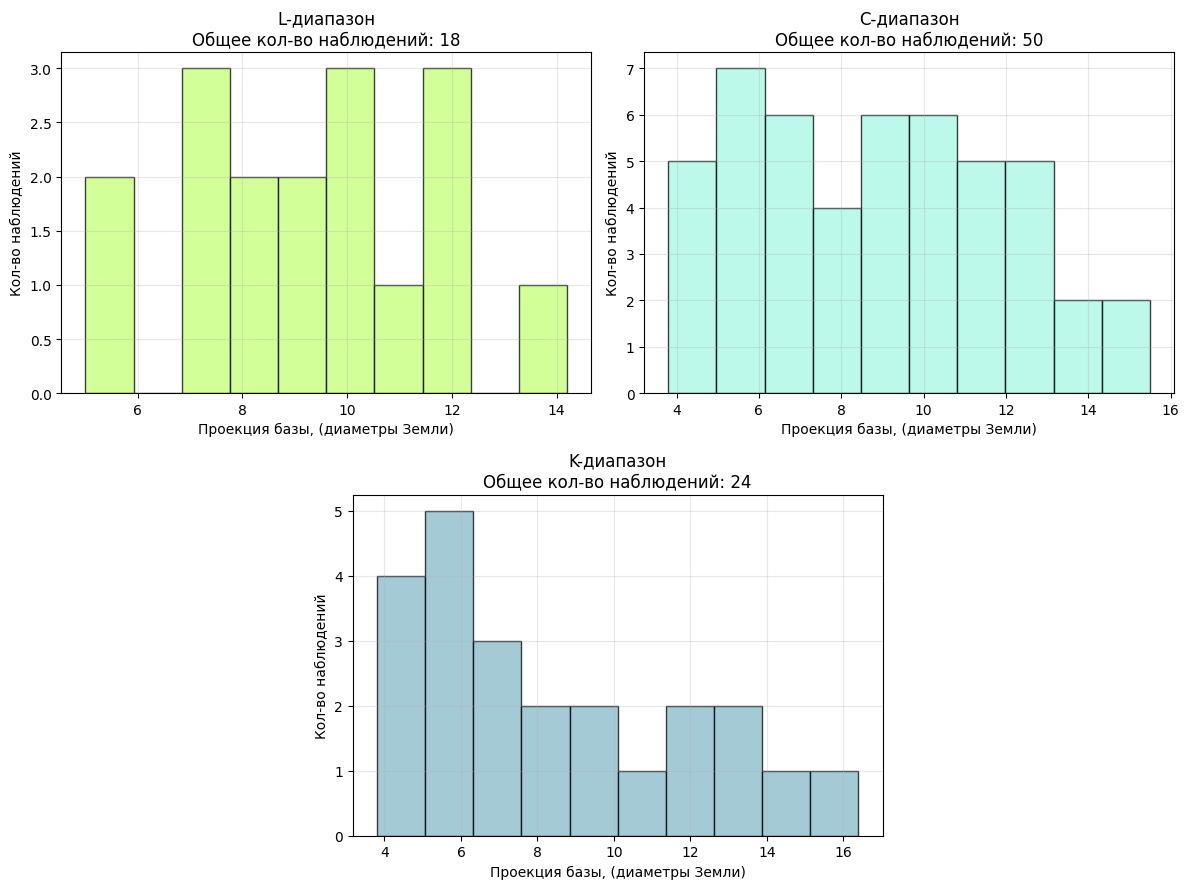

In [207]:
fig = plt.figure(figsize=(12, 9))

gs = fig.add_gridspec(2, 4)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])

axes = [ax1, ax2, ax3]

for i in range(3):
    band = bands_without_p[i]
    ax = axes[i]
    data = df[df[band] == 1]

    if len(data) > 1:
        color = band_colors.get(band, 'steelblue')
        ax.hist(data['BL'], bins=10, alpha=0.75,
                color=color, edgecolor='black')
        ax.set_title(f'{band}-диапазон\nОбщее кол-во наблюдений: {len(data)}')
        ax.set_xlabel('Проекция базы, (диаметры Земли)')
        ax.set_ylabel('Кол-во наблюдений')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data.', ha='center', va='center')

plt.tight_layout()
plt.show()

In [208]:
results = []

for band in bands:
    if band not in df.columns:
        continue
    total = len(df)
    valid = df[band].notna().sum()
    n0 = (df[band] == 0).sum()
    n1 = (df[band] == 1).sum()
    n2 = (df[band] == 2).sum()
    
    results.append({
        'Band': band,
        'Observed': valid,
        '0 (no correlation)': n0,
        '1 (space-ground)': n1,
        '2 (ground only)': n2
    })

stats_df = pd.DataFrame(results)
print("Correlation statistics per band:")
print(f"Total observations: {total}")
print(stats_df.round(1).to_string(index=False))

Correlation statistics per band:
Total observations: 92
Band  Observed  0 (no correlation)  1 (space-ground)  2 (ground only)
   P         3                   1                 1                1
   L        36                  11                18                7
   C        76                   6                50               20
   K        54                   8                24               22


## Angular Size and Brightness Temperature

### Angular Size

**Comment**: perform statistical analysis of estimated angular size of the source obtained by standard Gaussian model fit.

Angular Size Statistics per Frequency Band:
      Min_theta  Max_theta  Mean_theta  Std_theta   N
Band                                                 
C         0.076     12.375      1.0566     2.0190  43
K         0.015      5.470      0.3514     1.2416  19
L         0.390      9.866      2.2453     2.9435  10


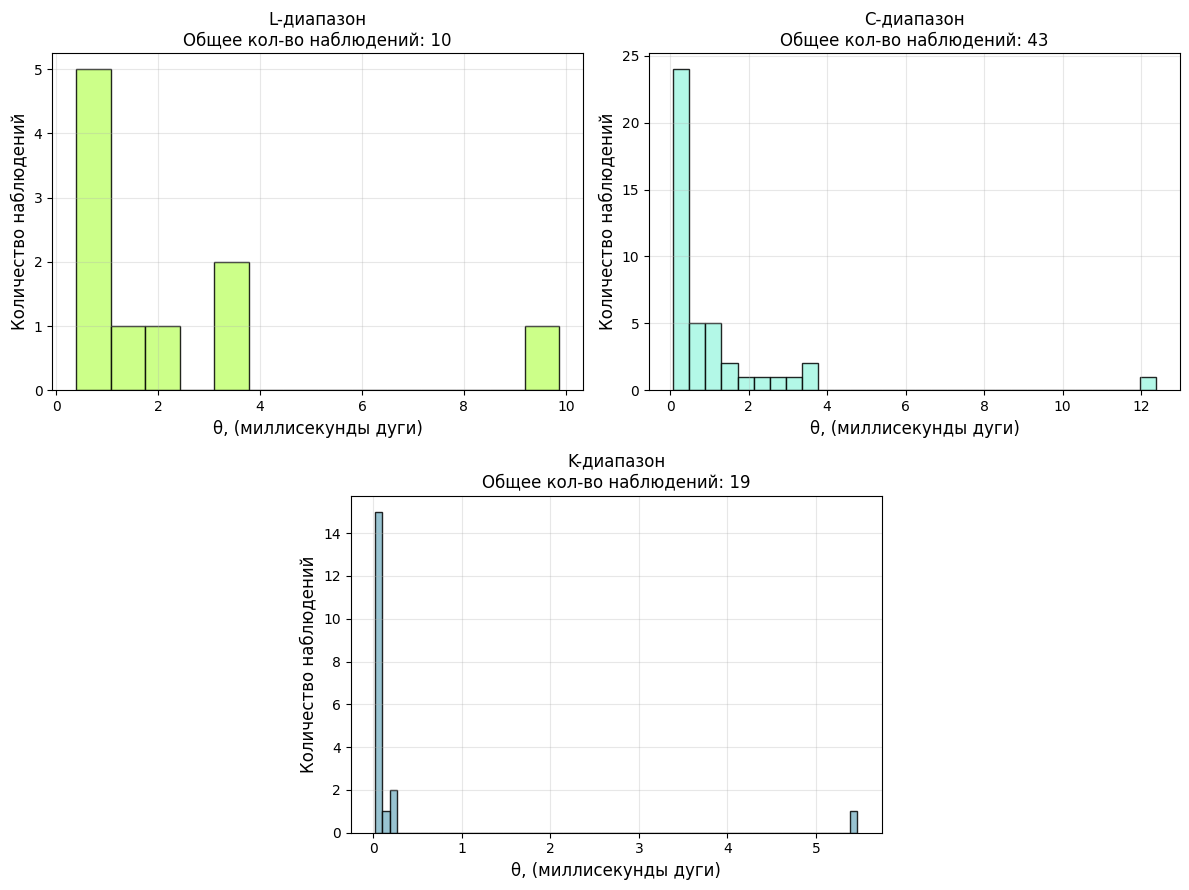

In [209]:
stats = ang.groupby('Band')['Theta_mas'].agg(['min', 'max', 'mean', 'std', 'count']).round(4)
stats = stats.rename(columns={
    'min': 'Min_theta',
    'max': 'Max_theta',
    'mean': 'Mean_theta',
    'std': 'Std_theta',
    'count': 'N'
})

print("Angular Size Statistics per Frequency Band:")
print(stats)

bins_dict = {
        'L': 14,
        'C': 30,
        'K': 64
        }

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 4)

ax1 = fig.add_subplot(gs[0, 0:2])   # L-band
ax2 = fig.add_subplot(gs[0, 2:4])   # C-band
ax3 = fig.add_subplot(gs[1, 1:3])   # K-band

axes = [ax1, ax2, ax3]
bands_to_plot = bands_without_p  # ['L', 'C', 'K']

for i, band in enumerate(bands_to_plot):
    ax = axes[i]
    subset = ang[ang['Band'] == band]['Theta_mas']
    
    if len(subset) > 0:
        color = band_colors.get(band, 'steelblue')
        bins = bins_dict.get(band, 20)
        
        ax.hist(subset, bins=bins, alpha=0.85, color=color, edgecolor='black')       
        ax.set_title(f'{band}-диапазон\nОбщее кол-во наблюдений: {len(subset)}')
        ax.set_xlabel('θ, (миллисекунды дуги)', fontsize=12)
        ax.set_ylabel('Количество наблюдений', fontsize=12)
        ax.grid(True, alpha=0.3)       
    else:
        ax.text(0.5, 0.5, 'No data for this band', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
plt.tight_layout()
plt.show()

--------------------------------
Frequency dependence of angular size
--------------------------------
Slope = -1.2032
ALPHA = 1.2032
Intercept = 4.0294
R² = 0.3909


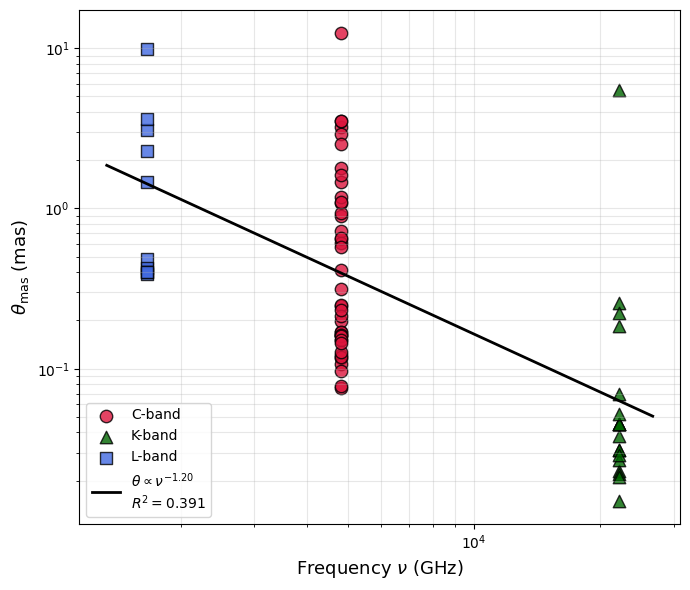

In [239]:
colors = {
    "L": "royalblue",
    "C": "crimson",
    "K": "darkgreen"
}

markers = {
    "L": "s",
    "C": "o",
    "K": "^"
}


# ----------------------------------------
# Подготовка данных
# ----------------------------------------

df = ang.copy()

df = df[
    (df["Frequency"] > 0) &
    (df["Theta_mas"] > 0)
]


x = np.log10(df["Frequency"].values)
y = np.log10(df["Theta_mas"].values)


# ----------------------------------------
# Линейная аппроксимация МНК
# log(theta)=a log(nu)+b
# alpha = -a
# ----------------------------------------

a, b = np.polyfit(x, y, 1)

y_fit = a*x + b


# R^2

ss_res = np.sum((y-y_fit)**2)
ss_tot = np.sum((y-np.mean(y))**2)

R2 = 1 - ss_res/ss_tot


alpha = -a


print("--------------------------------")
print("Frequency dependence of angular size")
print("--------------------------------")
print(f"Slope = {a:.4f}")
print(f"ALPHA = {alpha:.4f}")
print(f"Intercept = {b:.4f}")
print(f"R² = {R2:.4f}")


# ----------------------------------------
# График
# ----------------------------------------

fig, ax = plt.subplots(figsize=(7,6))


for band in sorted(df["Band"].unique()):

    m = df["Band"] == band

    ax.scatter(
        df.loc[m,"Frequency"],
        df.loc[m,"Theta_mas"],
        s=80,
        marker=markers.get(band,"o"),
        color=colors.get(band,"gray"),
        edgecolor="k",
        alpha=0.8,
        label=f"{band}-band"
    )


# линия МНК

nu_line = np.logspace(
    np.log10(df["Frequency"].min()*0.8),
    np.log10(df["Frequency"].max()*1.2),
    200
)

theta_line = 10**(
    a*np.log10(nu_line)+b
)


ax.plot(
    nu_line,
    theta_line,
    color="black",
    lw=2,
    label=(
        rf"$\theta \propto \nu^{{-{alpha:.2f}}}$"
        "\n"
        rf"$R^2={R2:.3f}$"
    )
)


ax.set_xscale("log")
ax.set_yscale("log")


ax.set_xlabel(
    r"Frequency $\nu$ (GHz)",
    fontsize=13
)

ax.set_ylabel(
    r"$\theta_{\rm mas}$ (mas)",
    fontsize=13
)


ax.grid(
    alpha=0.3,
    which="both"
)

ax.legend()

plt.tight_layout()
plt.show()

### Brightness Temperature

Add here estimations of brightness temperature

In [210]:
S = ang["A0"].astype(float)
S_err = ang["A0_err"].astype(float)

nu = ang["Frequency"].astype(float) / 1000.0

theta = ang["Theta_mas"].astype(float)
theta_err = ang["Theta_mas_err"].astype(float)

Tb = 1.22e12 * S / (nu**2 * theta**2)

Tb_err = Tb * np.sqrt(
    (S_err / S)**2 +
    (2 * theta_err / theta)**2
)

ang["Tb"] = Tb
ang["Tb_err"] = Tb_err

display(ang.head())

,Obs,Band,Date,Frequency,Theta_rad,Theta_rad_err,Theta_mas,Theta_mas_err,Y0,Y0_err,A0,A0_err,Tb,Tb_err
0,RAES03AA,C,2012-04-27,4828,5.623820e-10,6.043870e-12,0.116,0.001,0.00000,0.00000,1.82470,0.01301,7.097425e+12,1.324200e+11
1,RAES03AB,C,2012-04-28,4828,8.223090e-10,3.783600e-11,0.170,0.008,0.00000,0.00000,1.41168,0.01634,2.556606e+12,2.424345e+11
2,RAES03FW,C,2012-11-19,4828,3.105990e-09,9.651350e-10,0.641,0.199,0.04239,0.00535,2.34019,0.29095,2.980989e+11,1.887651e+11
3,RAES03FW,L,2012-11-19,1668,2.360400e-09,3.565680e-11,0.487,0.007,0.00000,0.00000,1.65010,0.00562,3.050845e+12,8.831733e+10
4,RAES03P,C,2012-04-04,4828,1.197850e-09,8.629210e-11,0.247,0.018,0.00000,0.00000,3.60793,0.05398,3.095206e+12,4.534937e+11


#### Dependency

-------------------------------------
Compact Flux Density A0 (Jy) vs $T_b$ (K)
Pearson : -0.166   p=0.1622
Spearman: -0.312   p=0.0077
-------------------------------------
$\theta$ (mas) vs $T_b$ (K)
Pearson : -0.364   p=0.0017
Spearman: -0.755   p=0.0000
-------------------------------------
$\theta$ (mas) vs Compact Flux Density A0 (Jy)
Pearson : 0.321   p=0.0060
Spearman: 0.575   p=0.0000


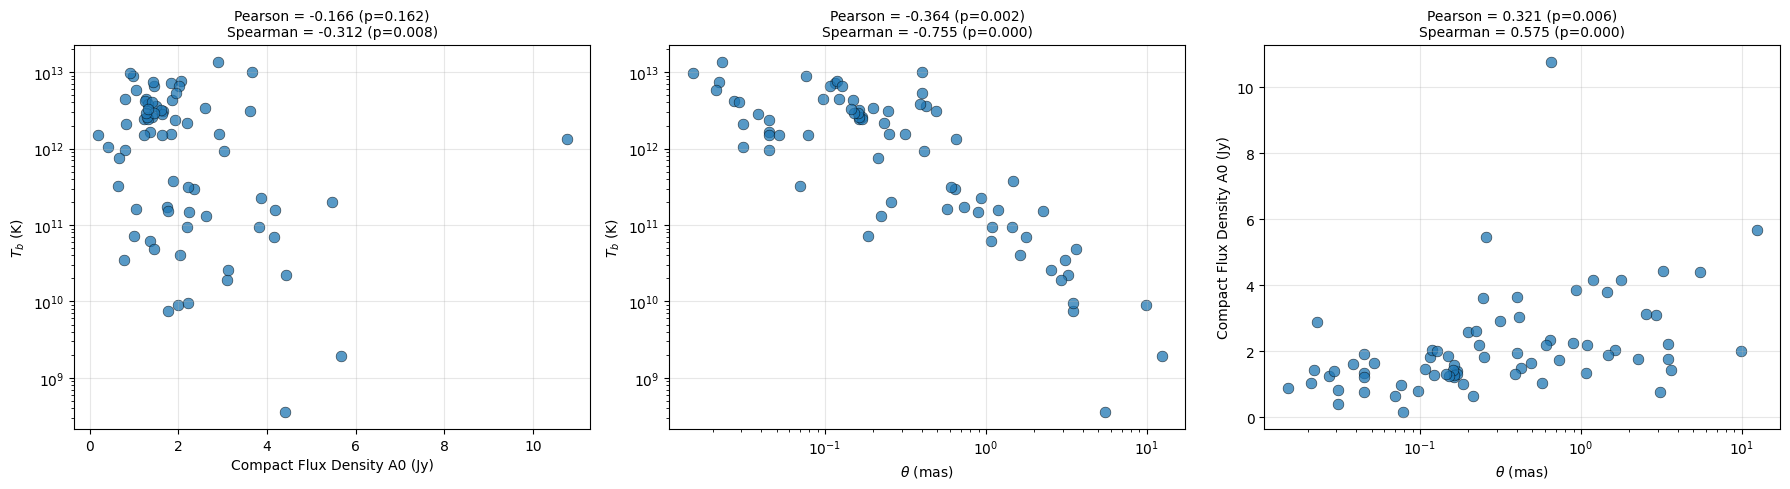

In [230]:
fig, axs = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

# Tb vs Flux

scatter_corr(
    axs[0],
    ang["A0"],
    ang["Tb"],
    "Compact Flux Density A0 (Jy)",
    r"$T_b$ (K)",
    logy=True
)

# Tb vs Size

scatter_corr(
    axs[1],
    ang["Theta_mas"],
    ang["Tb"],
    r"$\theta$ (mas)",
    r"$T_b$ (K)",
    logx=True,
    logy=True
)

# Flux vs Size

scatter_corr(
    axs[2],
    ang["Theta_mas"],
    ang["A0"],
    r"$\theta$ (mas)",
    "Compact Flux Density A0 (Jy)",
    logx=True
)

plt.tight_layout()

plt.show()


C-band
Pearson :  1.0000   p = 0.0000e+00
Spearman:  1.0000   p = 0.0000e+00

K-band
Pearson :  1.0000   p = 6.0790e-132
Spearman:  1.0000   p = 0.0000e+00

L-band
Pearson :  1.0000   p = 1.0635e-62
Spearman:  1.0000   p = 6.6469e-64


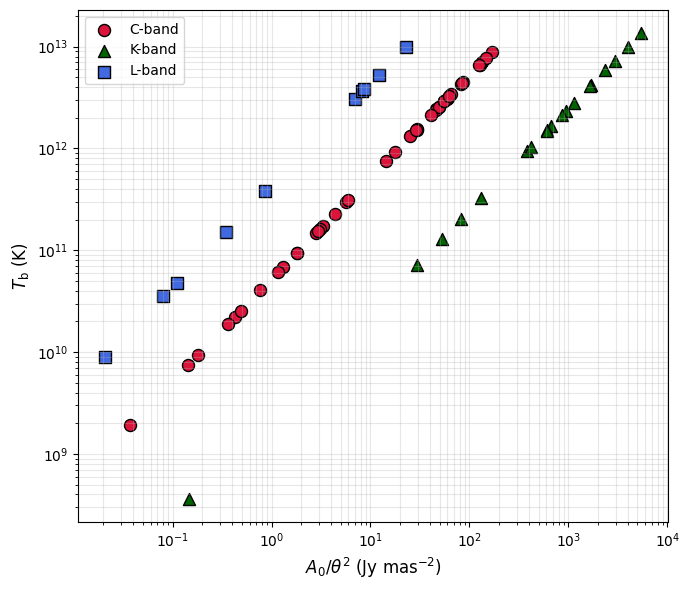

In [233]:
colors = {
    "L": "royalblue",
    "C": "crimson",
    "K": "darkgreen"
}

markers = {
    "L": "s",
    "C": "o",
    "K": "^"
}

fig, ax = plt.subplots(figsize=(7, 6))

for band in sorted(ang["Band"].unique()):

    m = ang["Band"] == band

    predictor = ang.loc[m, "A0"] / ang.loc[m, "Theta_mas"]**2

    Tb = ang.loc[m, "Tb"]

    ax.scatter(
        predictor,
        Tb,
        s=75,
        marker=markers.get(band, "o"),
        color=colors.get(band, "gray"),
        edgecolor="k",
        label=f"{band}-band"
    )

    # Корреляции
    if len(Tb) > 2:

        r, p = pearsonr(predictor, Tb)
        rs, ps = spearmanr(predictor, Tb)

        print(f"\n{band}-band")
        print(f"Pearson :  {r:.4f}   p = {p:.4e}")
        print(f"Spearman:  {rs:.4f}   p = {ps:.4e}")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$A_0/\theta^2$ (Jy mas$^{-2}$)", fontsize=12)
ax.set_ylabel(r"$T_{\rm b}$ (K)", fontsize=12)

ax.grid(alpha=0.3, which="both")
ax.legend()

plt.tight_layout()
plt.show()

L-band
Slope      = -2.0865
Intercept  = 11.8723
R²         = 0.9773
C-band
Slope      = -1.6895
Intercept  = 11.1231
R²         = 0.9430
K-band
Slope      = -1.7280
Intercept  = 9.8738
R²         = 0.9517


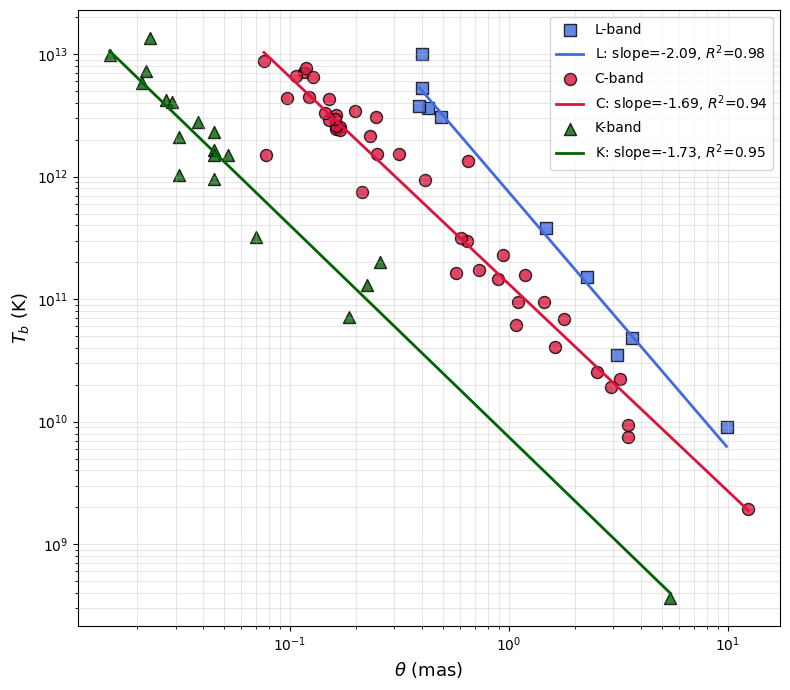

In [237]:
# ------------------------------------
# Цвета и маркеры диапазонов
# ------------------------------------

colors = {
    "L": "royalblue",
    "C": "crimson",
    "K": "darkgreen"
}

markers = {
    "L": "s",
    "C": "o",
    "K": "^"
}

# ------------------------------------
# График
# ------------------------------------

fig, ax = plt.subplots(figsize=(8, 7))

for band in ["L", "C", "K"]:

    m = (
        (ang["Band"] == band) &
        (ang["Theta_mas"] > 0) &
        (ang["Tb"] > 0)
    )

    theta = ang.loc[m, "Theta_mas"].values
    Tb = ang.loc[m, "Tb"].values

    # log10 координаты
    x = np.log10(theta)
    y = np.log10(Tb)

    # МНК: y = a*x+b
    a, b = np.polyfit(x, y, 1)

    # R^2
    y_fit = a*x + b

    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)

    R2 = 1 - ss_res/ss_tot


    # точки
    ax.scatter(
        theta,
        Tb,
        s=75,
        color=colors[band],
        marker=markers[band],
        edgecolor="k",
        alpha=0.8,
        label=f"{band}-band"
    )


    # линия МНК
    x_line = np.linspace(
        theta.min(),
        theta.max(),
        200
    )

    y_line = 10**(a*np.log10(x_line)+b)

    ax.plot(
        x_line,
        y_line,
        color=colors[band],
        lw=2,
        label=(
            f"{band}: slope={a:.2f}, "
            f"$R^2$={R2:.2f}"
        )
    )


    print("="*45)
    print(f"{band}-band")
    print(f"Slope      = {a:.4f}")
    print(f"Intercept  = {b:.4f}")
    print(f"R²         = {R2:.4f}")


# ------------------------------------
# Оформление
# ------------------------------------

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    r"$\theta$ (mas)",
    fontsize=13
)

ax.set_ylabel(
    r"$T_b$ (K)",
    fontsize=13
)

ax.grid(
    alpha=0.3,
    which="both"
)

ax.legend(
    fontsize=10
)

plt.tight_layout()
plt.show()

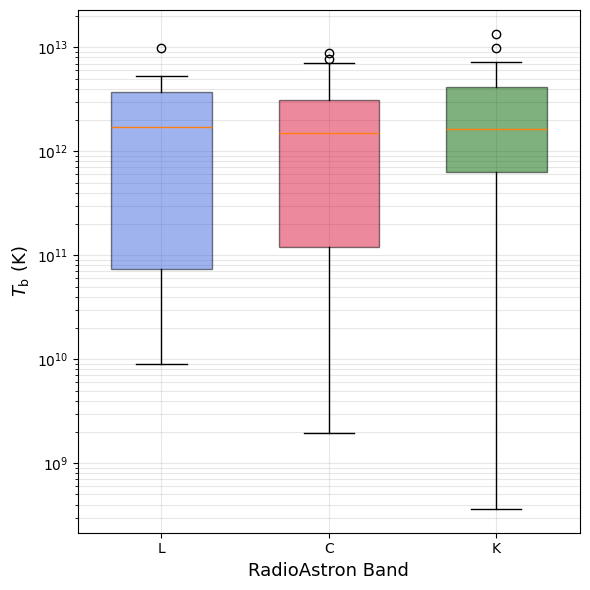

In [238]:
bands = ["L", "C", "K"]

data = [
    ang.loc[ang["Band"] == band, "Tb"]
    for band in bands
]

fig, ax = plt.subplots(figsize=(6,6))

bp = ax.boxplot(
    data,
    tick_labels=bands,
    patch_artist=True,
    showfliers=True,
    widths=0.6
)

colors = ["royalblue", "crimson", "darkgreen"]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

ax.set_yscale("log")

ax.set_ylabel(r"$T_{\rm b}$ (K)", fontsize=13)
ax.set_xlabel("RadioAstron Band", fontsize=13)

ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

In [236]:
bands = ["L", "C", "K"]

for band in bands:

    tb = ang.loc[ang["Band"] == band, "Tb"]

    print("="*40)
    print(f"{band}-band")
    print(f"N       = {len(tb)}")
    print(f"Median  = {tb.median():.3e}")
    print(f"Mean    = {tb.mean():.3e}")
    print(f"Std     = {tb.std():.3e}")
    print(f"Min     = {tb.min():.3e}")
    print(f"Max     = {tb.max():.3e}")

L-band
N       = 10
Median  = 1.715e+12
Mean    = 2.634e+12
Std     = 3.240e+12
Min     = 9.011e+09
Max     = 9.934e+12
C-band
N       = 43
Median  = 1.512e+12
Mean    = 2.102e+12
Std     = 2.396e+12
Min     = 1.938e+09
Max     = 8.782e+12
K-band
N       = 19
Median  = 1.646e+12
Mean    = 3.128e+12
Std     = 3.676e+12
Min     = 3.628e+08
Max     = 1.353e+13


### Light Curves

Add here comparison of brightness temperature vs. light curves at different bands (RATAN, photometry, X-ray, gamma-ray, etc.)

In [211]:
fermit = fermit.copy()
fermit["JD"] = fermit.iloc[:, 0] + 2400000.5

swift = swift.copy()
swift["JD"] = swift["BinCenter"] + 2400000.5

ang = ang.copy()
ang["JD"] = pd.to_datetime(ang["Date"]).apply(
    lambda x: x.to_julian_date()
)

# даты наблюдений RadioAstron
ra_dates = np.sort(ang["JD"].unique())

In [212]:
fermit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6171 entries, 0 to 6170
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MJD               6171 non-null   float64
 1   FLUX_100_300000   6171 non-null   float64
 2   ERROR_100_300000  6171 non-null   float64
 3   JD                6171 non-null   float64
dtypes: float64(4)
memory usage: 193.0 KB


In [213]:
fermit.head()

,MJD,FLUX_100_300000,ERROR_100_300000,JD
0,54688.500743,9.577098e-08,2.965300e-09,2.454689e+06
1,54689.500743,1.209674e-07,1.607956e-09,2.454690e+06
2,54690.500743,1.684671e-07,1.643102e-09,2.454691e+06
3,54691.500743,3.231207e-07,7.945157e-08,2.454692e+06
4,54692.500743,2.073799e-07,1.584371e-07,2.454693e+06


In [214]:
swift.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 879 entries, 0 to 878
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   BinCenter  879 non-null    float64
 1   BinHW      879 non-null    float64
 2   Rate       879 non-null    float64
 3   RateError  879 non-null    float64
 4   FracExp    879 non-null    object 
 5   Mode       0 non-null      float64
 6   JD         879 non-null    float64
dtypes: float64(6), object(1)
memory usage: 48.2+ KB


In [215]:
swift.head()

,BinCenter,BinHW,Rate,RateError,FracExp,Mode,JD
0,53510.609146,0.337761,0.08797,0.00561,0.06057 1,NaN,2.453511e+06
1,53516.720375,0.001148,0.33473,-1.00000,0.26554 1,NaN,2.453517e+06
2,53528.576849,0.007263,0.13670,0.01164,0.98262 1,NaN,2.453529e+06
3,54055.686960,0.011533,0.07643,0.00709,0.96553 1,NaN,2.454056e+06
4,54056.159880,0.142190,0.08622,0.00733,0.08897 1,NaN,2.454057e+06


In [216]:
ang.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Obs            72 non-null     object 
 1   Band           72 non-null     object 
 2   Date           72 non-null     object 
 3   Frequency      72 non-null     int64  
 4   Theta_rad      72 non-null     float64
 5   Theta_rad_err  72 non-null     float64
 6   Theta_mas      72 non-null     float64
 7   Theta_mas_err  72 non-null     float64
 8   Y0             72 non-null     float64
 9   Y0_err         72 non-null     float64
 10  A0             72 non-null     float64
 11  A0_err         72 non-null     float64
 12  Tb             72 non-null     float64
 13  Tb_err         72 non-null     float64
 14  JD             72 non-null     float64
dtypes: float64(11), int64(1), object(3)
memory usage: 8.6+ KB


In [217]:
ang.head()

,Obs,Band,Date,Frequency,Theta_rad,Theta_rad_err,Theta_mas,Theta_mas_err,Y0,Y0_err,A0,A0_err,Tb,Tb_err,JD
0,RAES03AA,C,2012-04-27,4828,5.623820e-10,6.043870e-12,0.116,0.001,0.00000,0.00000,1.82470,0.01301,7.097425e+12,1.324200e+11,2456044.5
1,RAES03AB,C,2012-04-28,4828,8.223090e-10,3.783600e-11,0.170,0.008,0.00000,0.00000,1.41168,0.01634,2.556606e+12,2.424345e+11,2456045.5
2,RAES03FW,C,2012-11-19,4828,3.105990e-09,9.651350e-10,0.641,0.199,0.04239,0.00535,2.34019,0.29095,2.980989e+11,1.887651e+11,2456250.5
3,RAES03FW,L,2012-11-19,1668,2.360400e-09,3.565680e-11,0.487,0.007,0.00000,0.00000,1.65010,0.00562,3.050845e+12,8.831733e+10,2456250.5
4,RAES03P,C,2012-04-04,4828,1.197850e-09,8.629210e-11,0.247,0.018,0.00000,0.00000,3.60793,0.05398,3.095206e+12,4.534937e+11,2456021.5


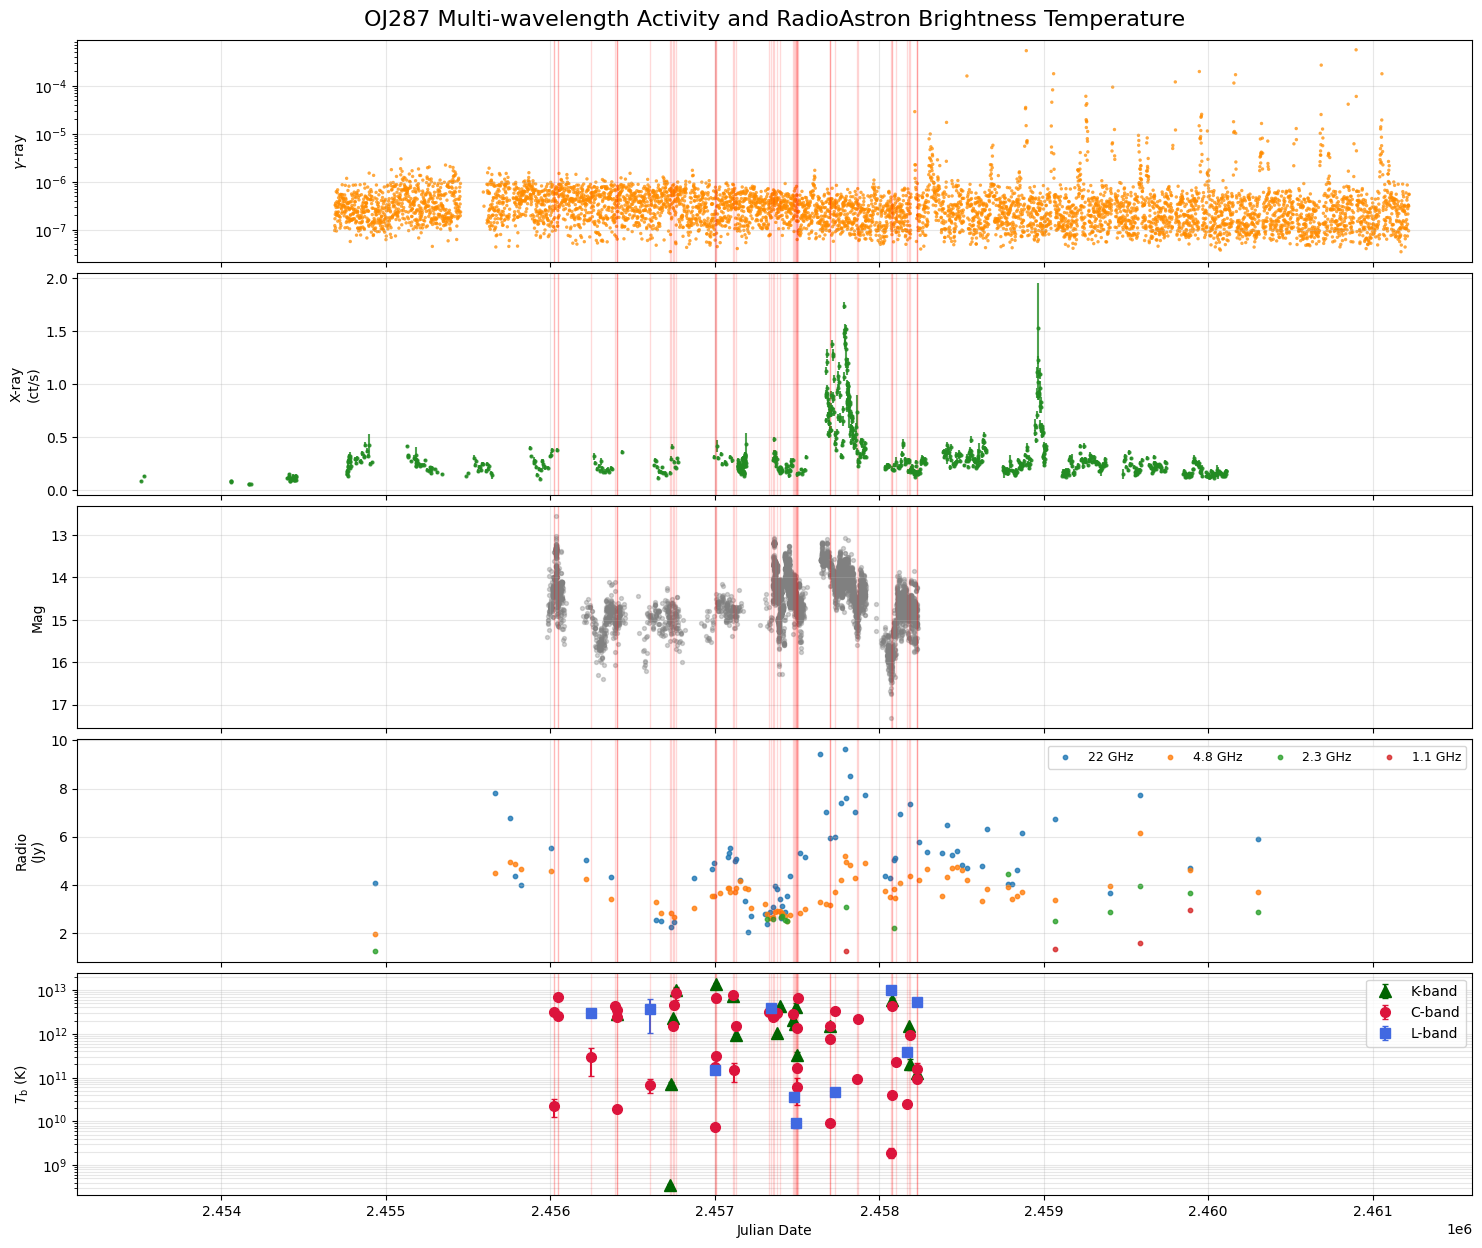

In [221]:


# =========================================================
# FIGURE
# =========================================================

fig, axes = plt.subplots(
    5,
    1,
    figsize=(18, 15),
    sharex=True,
    gridspec_kw={"hspace": 0.05}
)

ax0, ax1, ax2, ax3, ax4 = axes

# =========================================================
# FERMI
# =========================================================

ax0.scatter(
    fermit["JD"],
    fermit["FLUX_100_300000"],
    s=6,
    color="darkorange",
    alpha=0.75,
    edgecolors="none",
)

ax0.set_yscale("log")   # логарифмическая шкала по Y

ax0.set_ylabel(r"$\gamma$-ray")
ax0.grid(alpha=0.3)

# =========================================================
# SWIFT
# =========================================================

mask = swift["RateError"] > 0

ax1.errorbar(
    swift.loc[mask, "JD"],
    swift.loc[mask, "Rate"],
    yerr=swift.loc[mask, "RateError"],
    fmt=".",
    color="forestgreen",
    alpha=0.8,
    markersize=4,
)

ax1.set_ylabel("X-ray\n(ct/s)")
ax1.grid(alpha=0.3)

# =========================================================
# OPTICAL
# =========================================================

ax2.scatter(
    flux["JD"],
    flux["Magnitude"],
    s=8,
    color="gray",
    alpha=0.35,
)

ax2.invert_yaxis()
ax2.set_ylabel("Mag")
ax2.grid(alpha=0.3)

# =========================================================
# RATAN ALL FREQUENCIES
# =========================================================

ax3.scatter(
    ratan["JD"],
    ratan["Flux_22"],
    s=10,
    label="22 GHz",
    alpha=0.8,
)

ax3.scatter(
    ratan["JD"],
    ratan["Flux_4"],
    s=10,
    label="4.8 GHz",
    alpha=0.8,
)

ax3.scatter(
    ratan["JD"],
    ratan["Flux_2"],
    s=10,
    label="2.3 GHz",
    alpha=0.8,
)

ax3.scatter(
    ratan["JD"],
    ratan["Flux_1"],
    s=10,
    label="1.1 GHz",
    alpha=0.8,
)

ax3.set_ylabel("Radio\n(Jy)")
ax3.legend(
    ncol=4,
    fontsize=9,
    loc="upper right"
)
ax3.grid(alpha=0.3)

# =========================================================
# BRIGHTNESS TEMPERATURE
# =========================================================

mask_k = ang["Band"] == "K"
mask_c = ang["Band"] == "C"
mask_l = ang["Band"] == "L"

# K-band
ax4.errorbar(
    ang.loc[mask_k, "JD"],
    ang.loc[mask_k, "Tb"],
    yerr=ang.loc[mask_k, "Tb_err"],
    fmt="^",
    color="darkgreen",
    markersize=8,
    capsize=2,
    label="K-band",
)

# C-band
ax4.errorbar(
    ang.loc[mask_c, "JD"],
    ang.loc[mask_c, "Tb"],
    yerr=ang.loc[mask_c, "Tb_err"],
    fmt="o",
    color="crimson",
    markersize=7,
    capsize=2,
    label="C-band",
)

# L-band
ax4.errorbar(
    ang.loc[mask_l, "JD"],
    ang.loc[mask_l, "Tb"],
    yerr=ang.loc[mask_l, "Tb_err"],
    fmt="s",
    color="royalblue",
    markersize=7,
    capsize=2,
    label="L-band",
)

ax4.set_yscale("log")
ax4.set_ylabel(r"$T_{\rm b}$ (K)")
ax4.legend(loc="best")
ax4.grid(alpha=0.3, which="both")

# =========================================================
# RADIOASTRON EPOCHS
# =========================================================

for ax in axes:

    for jd in ra_dates:

        ax.axvline(
            jd,
            color="red",
            alpha=0.15,
            lw=1
        )

# =========================================================
# TITLE
# =========================================================

ax0.set_title(
    "OJ287 Multi-wavelength Activity and RadioAstron Brightness Temperature",
    fontsize=16,
    pad=10
)

ax4.set_xlabel("Julian Date")
plt.show()

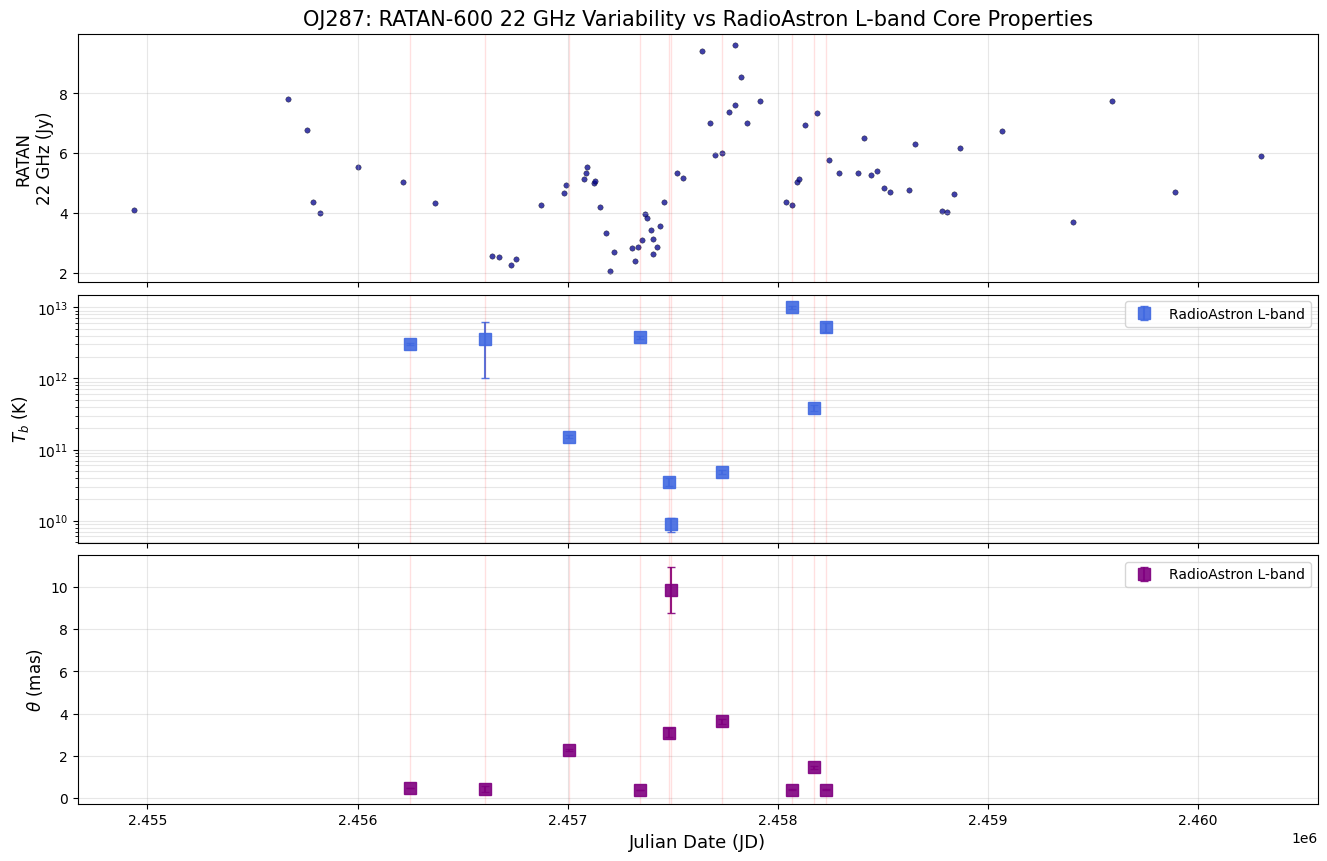

In [241]:
# -----------------------------
# L-band RadioAstron selection
# -----------------------------

l_band = ang[ang["Band"] == "L"].copy()


# =========================================================
# FIGURE
# =========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 10),
    sharex=True,
    gridspec_kw={"hspace":0.05}
)

ax0, ax1, ax2 = axes


# =========================================================
# RATAN 22 GHz
# =========================================================

ax0.scatter(
    ratan["JD"],
    ratan["Flux_22"],
    s=15,
    color="darkblue",
    alpha=0.75,
    edgecolors="k",
    linewidth=0.3
)

ax0.set_ylabel(
    "RATAN\n22 GHz (Jy)",
    fontsize=12
)

ax0.grid(alpha=0.3)



# =========================================================
# RadioAstron L-band Tb
# =========================================================

ax1.errorbar(
    l_band["JD"],
    l_band["Tb"],
    yerr=l_band["Tb_err"],
    fmt="s",
    color="royalblue",
    markersize=8,
    capsize=3,
    alpha=0.9,
    label="RadioAstron L-band"
)

ax1.set_yscale("log")

ax1.set_ylabel(
    r"$T_b$ (K)",
    fontsize=12
)

ax1.legend(
    loc="best"
)

ax1.grid(
    alpha=0.3,
    which="both"
)



# =========================================================
# RadioAstron L-band angular size
# =========================================================

ax2.errorbar(
    l_band["JD"],
    l_band["Theta_mas"],
    yerr=l_band["Theta_mas_err"],
    fmt="s",
    color="purple",
    markersize=8,
    capsize=3,
    alpha=0.9,
    label="RadioAstron L-band"
)


ax2.set_ylabel(
    r"$\theta$ (mas)",
    fontsize=12
)

ax2.set_xlabel(
    "Julian Date (JD)",
    fontsize=13
)

ax2.legend(
    loc="best"
)

ax2.grid(
    alpha=0.3
)



# =========================================================
# RadioAstron epochs
# =========================================================

for ax in axes:

    for jd in l_band["JD"]:

        ax.axvline(
            jd,
            color="red",
            alpha=0.12,
            lw=1
        )


# =========================================================
# TITLE
# =========================================================

ax0.set_title(
    "OJ287: RATAN-600 22 GHz Variability vs RadioAstron L-band Core Properties",
    fontsize=15
)

plt.show()

--------------------------------
Lag correlation Tb(L) vs RATAN 22 GHz
--------------------------------
Best Pearson lag = -80 days
Pearson r = -0.846
Spearman r = -0.543


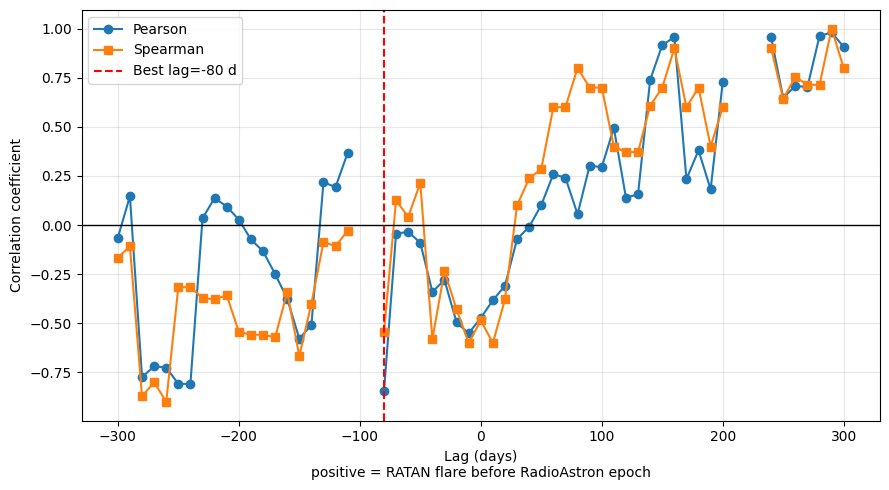

In [245]:
# =====================================================
# L-band RadioAstron
# =====================================================

l_band = ang[ang["Band"] == "L"].copy()


# =====================================================
# функция среднего RATAN потока вокруг эпохи
# =====================================================

def get_ratan_flux(jd, lag=0, window=15):

    center = jd - lag

    mask = (
        (ratan["JD"] >= center-window) &
        (ratan["JD"] <= center+window)
    )

    if mask.sum() == 0:
        return np.nan

    return ratan.loc[mask, "Flux_22"].mean()



# =====================================================
# лаги
# =====================================================

lags = np.arange(-300, 301, 10)


pearson_values = []
spearman_values = []


for lag in lags:

    flux_values = []

    for jd in l_band["JD"]:

        flux_values.append(
            get_ratan_flux(
                jd,
                lag=lag,
                window=15
            )
        )


    flux_values = np.array(flux_values)

    mask = np.isfinite(flux_values)


    if mask.sum() > 3:

        r, p = pearsonr(
            flux_values[mask],
            l_band.loc[mask, "Tb"]
        )

        rs, ps = spearmanr(
            flux_values[mask],
            l_band.loc[mask, "Tb"]
        )

    else:

        r = np.nan
        rs = np.nan


    pearson_values.append(r)
    spearman_values.append(rs)



# =====================================================
# лучший лаг
# =====================================================

best = np.nanargmin(pearson_values)

print("--------------------------------")
print("Lag correlation Tb(L) vs RATAN 22 GHz")
print("--------------------------------")

print(
    f"Best Pearson lag = {lags[best]} days"
)

print(
    f"Pearson r = {pearson_values[best]:.3f}"
)

print(
    f"Spearman r = {spearman_values[best]:.3f}"
)



# =====================================================
# график
# =====================================================

fig, ax = plt.subplots(figsize=(9,5))


ax.plot(
    lags,
    pearson_values,
    marker="o",
    label="Pearson"
)


ax.plot(
    lags,
    spearman_values,
    marker="s",
    label="Spearman"
)


ax.axhline(
    0,
    color="black",
    lw=1
)


ax.axvline(
    lags[best],
    color="red",
    ls="--",
    label=f"Best lag={lags[best]} d"
)


ax.set_xlabel(
    "Lag (days)\npositive = RATAN flare before RadioAstron epoch"
)

ax.set_ylabel(
    "Correlation coefficient"
)


ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()

plt.show()

In [242]:
# -----------------------------
# L-band RadioAstron
# -----------------------------

l_band = ang[ang["Band"] == "L"].copy()


# -----------------------------
# ближайший RATAN 22 GHz
# -----------------------------

ratan_l = []

for jd in l_band["JD"]:

    idx = np.abs(ratan["JD"] - jd).argmin()

    ratan_l.append(
        ratan.iloc[idx]["Flux_22"]
    )


l_band["RATAN22_nearest"] = ratan_l


# -----------------------------
# корреляции
# -----------------------------

x = l_band["RATAN22_nearest"]
y = l_band["Tb"]


pear = pearsonr(x,y)
spear = spearmanr(x,y)


print("Tb(L-band) vs RATAN 22 GHz")
print("--------------------------------")
print(f"Pearson  r={pear.statistic:.3f}, p={pear.pvalue:.4f}")
print(f"Spearman r={spear.statistic:.3f}, p={spear.pvalue:.4f}")


l_band[
    [
        "JD",
        "Tb",
        "Theta_mas",
        "A0",
        "RATAN22_nearest"
    ]
]

Tb(L-band) vs RATAN 22 GHz
--------------------------------
Pearson  r=-0.361, p=0.3060
Spearman r=-0.358, p=0.3104


,JD,Tb,Theta_mas,A0,RATAN22_nearest
3,2456250.5,3.050845e+12,0.487,1.65010,5.05
12,2456605.5,3.630544e+12,0.426,1.50253,2.56
22,2457003.5,1.511014e+11,2.270,1.77563,4.92
32,2457343.5,3.800490e+12,0.390,1.31826,2.86
40,2457479.5,3.527262e+10,3.106,0.77602,4.37
43,2457492.5,9.011384e+09,9.866,2.00035,5.34
54,2457731.5,4.815945e+10,3.632,1.44879,5.99
58,2458068.5,9.933799e+12,0.402,3.66100,4.28
63,2458170.5,3.800399e+11,1.472,1.87792,7.34
70,2458228.5,5.301219e+12,0.402,1.95371,5.76


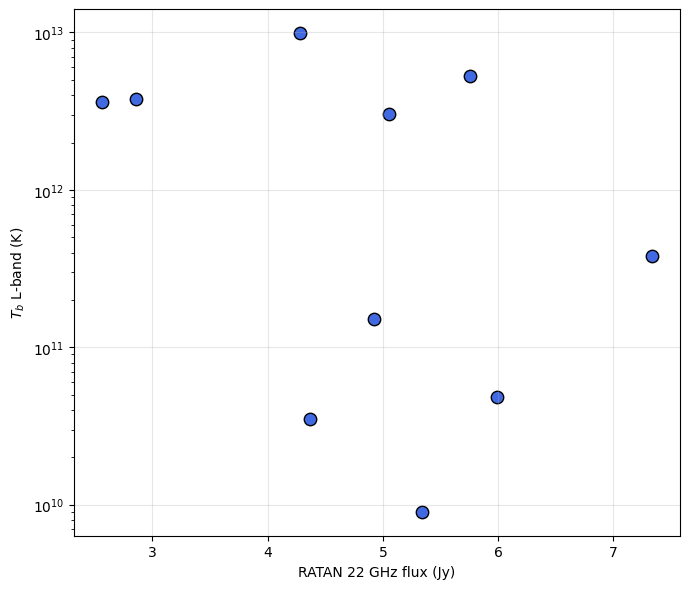

In [243]:
fig, ax = plt.subplots(figsize=(7,6))


ax.scatter(
    l_band["RATAN22_nearest"],
    l_band["Tb"],
    s=80,
    color="royalblue",
    edgecolor="k"
)


ax.set_xlabel(
    "RATAN 22 GHz flux (Jy)"
)

ax.set_ylabel(
    r"$T_b$ L-band (K)"
)


ax.set_yscale("log")

ax.grid(alpha=0.3)


plt.tight_layout()

plt.show()

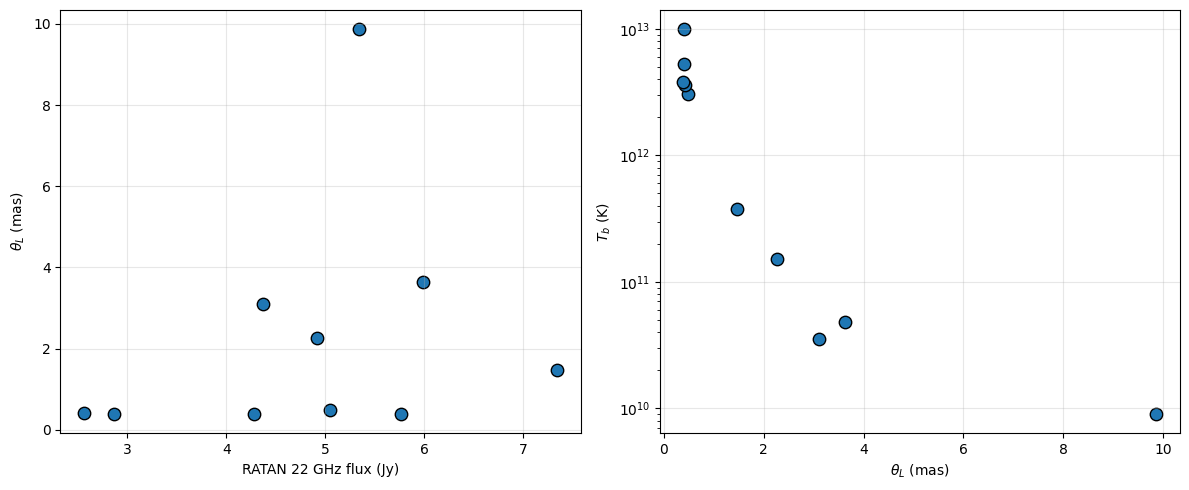

In [244]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)


# Flux vs theta

axes[0].scatter(
    l_band["RATAN22_nearest"],
    l_band["Theta_mas"],
    s=80,
    edgecolor="k"
)

axes[0].set_xlabel(
    "RATAN 22 GHz flux (Jy)"
)

axes[0].set_ylabel(
    r"$\theta_L$ (mas)"
)

axes[0].grid(alpha=0.3)



# theta vs Tb

axes[1].scatter(
    l_band["Theta_mas"],
    l_band["Tb"],
    s=80,
    edgecolor="k"
)

axes[1].set_xlabel(
    r"$\theta_L$ (mas)"
)

axes[1].set_ylabel(
    r"$T_b$ (K)"
)

axes[1].set_yscale("log")

axes[1].grid(alpha=0.3)


plt.tight_layout()

plt.show()